In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np
import json
import re

import sys
import os

# Ajout du dossier GNN au path pour permettre l'import direct de 'forecasting_models'
# Cela suppose que le notebook est dans le dossier 'Prediction' et que 'GNN' est un sous-dossier.
gnn_path = os.path.abspath('GNN')

if gnn_path not in sys.path:
    sys.path.insert(0, gnn_path)

print(f"Added to sys.path: {gnn_path}")

Added to sys.path: /home/caron/Bureau/ST-GNN-for-wildifre-prediction/Prediction/GNN


In [17]:

import datetime as dt
import numpy as np

def find_dates_between(start, end):
    start_date = dt.datetime.strptime(start, '%Y-%m-%d').date()
    end_date = dt.datetime.strptime(end, '%Y-%m-%d').date()

    delta = dt.timedelta(days=1)
    date = start_date
    res = []
    while date < end_date:
            res.append(date.strftime("%Y-%m-%d"))
            date += delta
    return res
    
def num_zone2_num_zone(df):
    dico = {}
    if 'departement' in df.columns:
         num_zones = np.sort(np.unique(df[df['departement'] == 6]['graph_id']))
         num_zone = [65,62,64,61,66,67,63]
         for i, gi in enumerate(num_zones):
             if i < len(num_zone):
                dico[gi] = num_zone[i]
    
    if 'graph_id' in df.columns:
        num_zones_all = np.unique(df['graph_id'])
        for gi in num_zones_all:
            if gi not in dico:
                dico[gi] = gi

    df['num_zone'] = df['graph_id'].map(dico)
    return df


In [18]:
import pickle

MODE = 'bdiff'

def _run_and_save_predictions(model, resolved_target: str):
    """
    Runs multi-horizon predictions and saves results in model.df_test.
    Follows logic from GNN.dataloader.test_dl_model.
    """
    from GNN.dataloader import filter_prediction
    from GNN.config import date_index, graph_id_index, scale_index, weight_index
    
    df_test = model.df_test
    target_col = TARGET_COLUMNS.get(resolved_target, resolved_target)
    
    # Run predictions with return_y=True for alignment
    pred_tensor, y_tensor = model.predict(df_test, return_y=True)
    
    # Run probabilities
    try:
        pred_proba_tensor, _ = model.predict_proba(df_test, return_y=True)
    except Exception:
        pred_proba_tensor = None

    # Convert to numpy
    if hasattr(y_tensor, 'detach'):
        y_tensor = y_tensor.detach().cpu().numpy()
    if hasattr(pred_tensor, 'detach'):
        pred_tensor = pred_tensor.detach().cpu().numpy()
    if pred_proba_tensor is not None and hasattr(pred_proba_tensor, 'detach'):
        pred_proba_tensor = pred_proba_tensor.detach().cpu().numpy()

    # Mock graphScale for filter_prediction
    class MockGS:
        def __init__(self):
            self.graph_method = graph_construct
            self.base = scale
            self.scale = scale

    # Align predictions
    pred_all, y_all, df_filtered = filter_prediction(MockGS(), df_test, pred_tensor, y_tensor, None, None)
    
    if pred_proba_tensor is not None:
        pred_proba_all, _, _ = filter_prediction(MockGS(), df_test, pred_proba_tensor, y_tensor, None, None)
    else:
        pred_proba_all = None

    horizon = model.horizon if hasattr(model, "horizon") else 0
    
    # Add columns for each horizon
    for H in range(horizon + 1):
        idx = -1 - (horizon - H)
        
        col_base = f"prediction_{target_col}_{H}"
        df_filtered[col_base] = pred_all[:, idx]
        
        if pred_proba_all is not None:
            for c in range(pred_proba_all.shape[-1]):
                df_filtered[f"{col_base}_C{c}"] = pred_proba_all[:, idx, c]
                
    full_df = pd.concat((model.df_train, model.df_val, model.df_test)).reset_index(drop=True)

    return df_filtered, model.df_train, full_df

clustering = "kmeans"

clustering_suffix = f'{clustering}-5-Class-Dept'

TARGET_COLUMNS = {
    'nbsinister': f'nbsinister-{clustering_suffix}',
    'timeintervention': f'timeintervention-{clustering_suffix}',
    'DFE': 'DFE',
    'ressource': f'ressource-{clustering_suffix}',
    'burnedareaRoot': f'burnedareaRoot-{clustering_suffix}',
    'burnedarea': f'burnedarea-{clustering_suffix}',
}

if MODE == '06' or MODE == 'bdiff':
    import pickle
    
    scale = "3"
    graph_construct = "zonemeteo"
    horizon_train = '0'
    kdays = '10'
    under_sampling = "full"
    expe = "062023"
    
    loss = 'bceloss'

    departement = '{departement}'
    
    fire_df, train_fire_df, full_fire_df = _run_and_save_predictions(pickle.load(open(f'GNN/firemen/firepoint/2x2/train/occurence_{expe}/check_z-score/full_all_{scale}_0_{graph_construct}_node/GRU_search_full_10_0_all_one_nbsinister-quantile-5-Class-Dept_classification_{loss}/GRU_search_full_10_0_all_one_nbsinister-quantile-5-Class-Dept_classification_{loss}.pkl', 'rb')), 'nbsinister')
    #res_df, train_res_df, full_res_df = _run_and_save_predictions(pickle.load(open(f'GNN/firemen/firepoint/2x2/train/occurence_{expe}/check_z-score/full_all_{scale}_0_{graph_construct}_node/GRU_full_full_10_0_all_one_ressource-quantile-5-Class-Dept_classification_flwki-id{departement}/GRU_full_full_10_0_all_one_ressource-quantile-5-Class-Dept_classification_flwki-id{departement}.pkl', 'rb')), 'ressource')
    #time_df, train_time_df, full_time_df = _run_and_save_predictions(pickle.load(open(f'GNN/firemen/firepoint/2x2/train/occurence_{expe}/check_z-score/full_all_{scale}_0_{graph_construct}_node/GRU_full_full_10_0_all_one_timeintervention-quantile-5-Class-Dept_classification_flwki-id{departement}/GRU_full_full_10_0_all_one_timeintervention-quantile-5-Class-Dept_classification_flwki-id{departement}.pkl', 'rb')), 'timeintervention')
    dfe_df, dfe_train, full_dfe_df = _run_and_save_predictions(pickle.load(open(f'GNN/firemen/firepoint/2x2/train/occurence_06/check_z-score/full_all_{scale}_0_{graph_construct}_node/GRU_full_full_10_0_all_one_DFE_classification_wkloss/GRU_full_full_10_0_all_one_DFE_classification_wkloss.pkl', 'rb')), 'DFE')

if MODE == 'bdiff':
    scale = "departement"
    expe = "default"
    graph_construct = "None"


    fire_df, train_fire_df, full_fire_df = _run_and_save_predictions(pickle.load(open(f'GNN/bdiff/firepoint/2x2/train/occurence_{expe}/check_z-score/full_all_{scale}_0_None_node/GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_flwk/GRU_search_full_10_0_all_one_nbsinister-kmeans-5-Class-Dept_classification_flwk.pkl', 'rb')), 'nbsinister')
    #res_df, train_res_df, full_res_df = _run_and_save_predictions(pickle.load(open(f'GNN/bdiff/firepoint/2x2/train/occurence_{expe}/check_z-score/full_all_departement_0_None_node/GRU_full_full_10_0_all_one_ressource-quantile-5-Class-Dept_classification_flwki-id{departement}/GRU_full_full_10_0_all_one_ressource-quantile-5-Class-Dept_classification_flwki-id{departement}.pkl', 'rb')), 'ressource')
    #res_df, train_res_df, full_res_df = _run_and_save_predictions(pickle.load(open(f'GNN/bdiff/firepoint/2x2/train/occurence_{expe}/check_z-score/full_all_departement_0_None_node/GRU_full_full_10_0_all_one_ressource-quantile-5-Class-Dept_classification_flwki-id{departement}/GRU_full_full_10_0_all_one_ressource-quantile-5-Class-Dept_classification_flwki-id{departement}.pkl', 'rb')), 'ressource')
    #time_df, train_time_df, full_time_df = _run_and_save_predictions(pickle.load(open(f'GNN/bdiff/firepoint/2x2/train/occurence_{expe}/check_z-score/full_all_departement_0_None_node/GRU_full_full_10_0_all_one_timeintervention-quantile-5-Class-Dept_classification_flwki-id{departement}/GRU_full_full_10_0_all_one_timeintervention-quantile-5-Class-Dept_classification_flwki-id{departement}.pkl', 'rb')), 'timeintervention')

In [19]:
######## A APPLIQUER A TOUT LES DATAFRAMES CHARGE (GRU + STATS_MODELS) ##########

# Process Dates for DFE
"""allDates_dfe = find_dates_between('2017-06-12', '2024-12-31')
full_dfe_df['date'] = full_dfe_df['date'].apply(lambda x : allDates_dfe[x] if x < len(allDates_dfe) else None)
full_dfe_df['date'] = pd.to_datetime(full_dfe_df['date'])
full_dfe_df['num_zone'] = full_dfe_df['num_zone']

full_dfe_df = full_dfe_df[full_dfe_df['date'] >= '2018-01-01']"""

# Process Dates for Fire/Time/Res
allDates_fire = find_dates_between('2017-06-12', '2024-12-31')

dfs = [
    "full_fire_df",
    #"full_dfe_df",
    #"train_fire_df",
    "full_dfe_df"
]

for name in dfs:
    df = globals().get(name, None)
    
    if df is None:
        continue

    # sécurise aussi si colonne absente
    if 'date' in df.columns:
        df['date'] = df['date'].apply(
            lambda x: allDates_fire[x] if pd.notna(x) and x < len(allDates_fire) else None
        )
        df['date'] = pd.to_datetime(df['date'])

    df = num_zone2_num_zone(df)

    # remet à jour la variable originale
    globals()[name] = df

In [20]:
full_fire_df[full_fire_df['date'] >= '2024-01-12']['DFE'].unique()

array([nan])

In [21]:
full_fire_df.columns

Index(['Châtaignier_max', 'Chênes décidus_max', 'Chênes décidus_mean',
       'Chênes sempervirents_max', 'Conifères_max', 'Conifères_mean',
       'Corine_agricultural_max', 'Corine_agricultural_mean',
       'Corine_forest_max', 'Corine_forest_mean',
       ...
       'burnedareaRoot-kmeans-5-Class-Season_prev_0',
       'burnedareaRoot-kmeans-5-Class-Season_prev_1',
       'burnedareaRoot-kmeans-5-Class-Season_prev_2',
       'burnedareaRoot-kmeans-5-Class-Season_prev_3',
       'burnedareaRoot-kmeans-5-Class-Season_prev_4',
       'timeintervention-kmeans-5-Class-Dept', 'ressource', 'class', 'DFE',
       'num_zone'],
      dtype='object', length=460)

In [22]:
full_fire_df['nbsinister'].std()

0.34999595755214874

In [23]:
KEYS = ["date", "num_zone"] ######" NE CHANGE PAS ##########

#columns = ['nbsinister', 'ressource', 'time_intervention',  f'nbsinister-{clustering_suffix}', f'timeintervention-{clustering_suffix}', f'ressource-{clustering_suffix}']

#train_fire_df_key = full_fire_df[KEYS + columns]

#full_dfe_df = full_dfe_df.merge(train_fire_df_key, on=KEYS, how='left')

In [24]:
import numpy as np, pickle, copy as _copy
from pathlib import Path
from forecasting_models.sklearn.score import Scoring

# Un scorer par target —  sigma et référence définis sur le dataset complet
target_setup = {
    'Fire':      ('nbsinister',        'full_fire_df',  'train_fire_df'),
    'BurnedArea': ('burnedareaRoot',          'full_fire_df',  'train_fire_df'),
}

min_n = globals().get('min_n', 1)

scorers = {}   # scorers['Fire'], scorers['Ressource'], scorers['Time']

for label, (target_col, df_name, train_name) in target_setup.items():
    df       = globals().get(df_name)
    train_df = globals().get(train_name)
    if df is None or target_col not in df.columns:
        print(f"[setup] {label}: df absent, skipped"); continue

    sc = Scoring()

    # sigma sur train (ou df entier si train absent)
    _src = train_df if (train_df is not None and target_col in train_df.columns) else df
    sc.set_sigma(float(np.std(_src[target_col].fillna(0))))

    # Reference sur df entier : {target}-quantile-5-Class-Dept
    df_c = df.copy()
    df_c['date'] = pd.to_datetime(df_c['date'])
    ref_col = f'{target_col}-kmeans-5-Class-Dept'
    if ref_col in df_c.columns:
        _r = df_c.dropna(subset=[ref_col, target_col, 'date', 'num_zone'])
        sc.evaluation_scoring(
            _r[ref_col].astype(float), _r[target_col].fillna(0),
            _r['date'], _r['num_zone'], min_n=min_n, reference=True
        )
        print(f"[setup] {label}: sigma={sc.sigma:.4f}  pair_mean_deltas={sc.pair_mean_deltas}")
    else:
        print('ERROR')
        
    scorers[label] = sc

    # Sauvegarde
    out = Path(MODE) / f'scorer_{label}.pkl'
    out.parent.mkdir(exist_ok=True)
    pickle.dump(sc, open(out, 'wb'))
    print(f"  saved -> {out}")
    
print(f"\nScoers ready: {list(scorers.keys())}")


[setup] Fire: sigma=0.3795  pair_mean_deltas={(0, 1): 2.6279656506423876, (1, 2): 2.8215566048741394, (2, 3): 3.9084656828110553, (3, 4): 7.664776921069635, (0, 2): 5.449522255516527, (1, 3): 6.730022287685195, (2, 4): 11.57324260388069, (0, 3): 9.357987938327582, (1, 4): 14.39479920875483, (0, 4): 17.022764859397217}
  saved -> bdiff/scorer_Fire.pkl
[setup] BurnedArea: sigma=73.3868  pair_mean_deltas={(0, 1): 0.5443217000925245, (1, 2): 2.3185576414210374, (2, 3): 3.5952861060380528, (3, 4): 8.473923528165347, (0, 2): 2.862879341513562, (1, 3): 5.91384374745909, (2, 4): 12.0692096342034, (0, 3): 6.458165447551615, (1, 4): 14.387767275624437, (0, 4): 14.932088975716962}
  saved -> bdiff/scorer_BurnedArea.pkl

Scoers ready: ['Fire', 'BurnedArea']


In [25]:
PLOT = False
from pathlib import Path

if PLOT:

    # Plot fitted spline for each experiment (score in [0,4])
    # This cell plots the marginal fitted mean (averaged over zone/date) for scores in [0,4]
    import numpy as np
    import matplotlib.pyplot as plt

    targets = ['nbsinister', 'ressource', 'time_intervention', 'DFE']
    # prediction fits from evaluation_scoring
    pred_fits = {
        'nbsinister': globals().get('fit_fire', None),
        'ressource': globals().get('fit_res', None),
        'time_intervention': globals().get('fit_time', None),
    }

    xs = np.linspace(0, 4, 200)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for i, target in enumerate(targets):
        ax = axes[i]

        # DFE fit (trained on dfe_train)
        fit_d = None
        try:
            fit_d = fit_dfe.get(target)
        except Exception:
            fit_d = None

        # Prediction fit (fire/res/time)
        fit_p = pred_fits.get(target)

        plotted_any = False

        def mean_pred_over_template(fit_obj, xs):
            # build a template from the data used to fit (zone/date) and return mean predictions
            try:
                df_template = fit_obj.model.data.frame[['zone', 'date']].drop_duplicates().copy()
            except Exception:
                # fallback: try to get unique zone/date from the global dfs if available
                if target == 'DFE' and 'dfe_train' in globals():
                    df_template = dfe_train[['num_zone', 'date']].rename(columns={'num_zone':'zone'}).drop_duplicates().copy()
                    df_template['zone'] = df_template['zone'].astype('category')
                elif target in ['nbsinister', 'ressource', 'time_intervention']:
                    dfname = {'nbsinister': 'fire_df', 'ressource': 'res_df', 'time_intervention': 'time_df'}[target]
                    if dfname in globals():
                        tmpdf = globals()[dfname]
                        df_template = tmpdf[['num_zone', 'date']].rename(columns={'num_zone':'zone'}).drop_duplicates().copy()
                        df_template['zone'] = df_template['zone'].astype('category')
                    else:
                        return None
            preds = []
            for x in xs:
                tmp = df_template.copy()
                tmp['score'] = float(x)
                try:
                    preds.append(fit_obj.predict(tmp).mean())
                except Exception:
                    return None
            return np.array(preds)

        if fit_d is not None:
            preds_d = mean_pred_over_template(fit_d, xs)
            if preds_d is not None:
                ax.plot(xs, preds_d, label='DFE fit', color='C0')
                plotted_any = True

        if fit_p is not None:
            preds_p = mean_pred_over_template(fit_p, xs)
            if preds_p is not None:
                ax.plot(xs, preds_p, label='prediction fit', color='C1', linestyle='--')
                plotted_any = True

        if not plotted_any:
            ax.text(0.5, 0.5, 'No fit available', ha='center', va='center')

        ax.set_title(target)
        ax.set_xlabel('score')
        ax.set_ylabel('predicted Y')
        ax.legend()

    plt.tight_layout()
    plt.show()

In [26]:
full_res_df = full_fire_df.copy(deep=True)
full_time_df = full_fire_df.copy(deep=True)

FWI Scoring Analysis

--- FWI / Fire ---
  sigma=0.3795  pair_mean_deltas={(0, 1): 2.6279656506423876, (1, 2): 2.8215566048741394, (2, 3): 3.9084656828110553, (3, 4): 7.664776921069635, (0, 2): 5.449522255516527, (1, 3): 6.730022287685195, (2, 4): 11.57324260388069, (0, 3): 9.357987938327582, (1, 4): 14.39479920875483, (0, 4): 17.022764859397217}
  Global: high=0.2044  k1=0.0513  recall=0.9288
Dataset    score_high     score_low  score_min_class   recall            k1            k2            k3        k4  cov_k1  cov_k2  cov_k3  cov_k4
 Global  2.043917e-01  1.221093e-01              1.0 0.928766  5.131489e-02  7.079444e-02  9.118104e-02  0.113211  128375   64192   12839    2568
   2017  2.366238e-01  1.289326e-01              1.0 0.986416  4.571586e-02  8.321676e-02  1.101897e-01  0.126434   10527    4992    1038     308
 2017_1 -7.650770e-10 -2.334548e-09              1.0 1.000000 -1.973155e-09 -3.613928e-10 -7.650770e-10  0.000000     113      54       2       0
 2017_2  0.000000e+

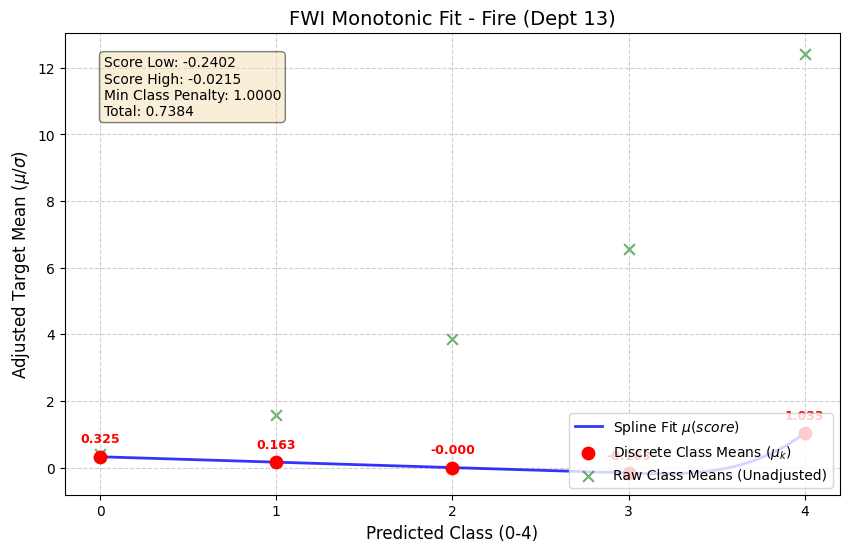

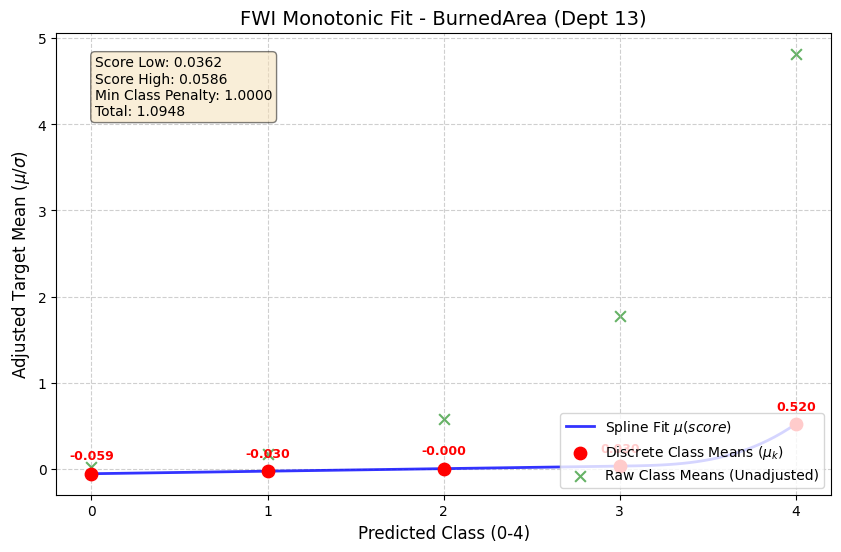

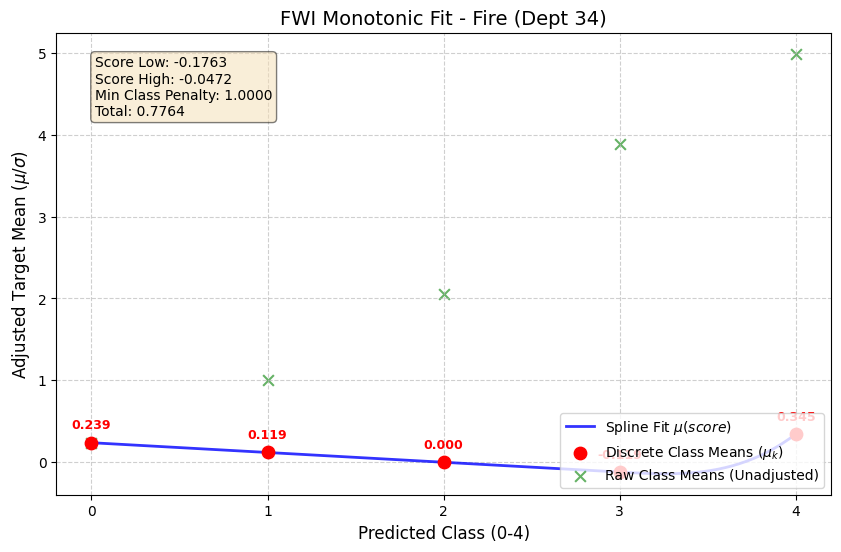

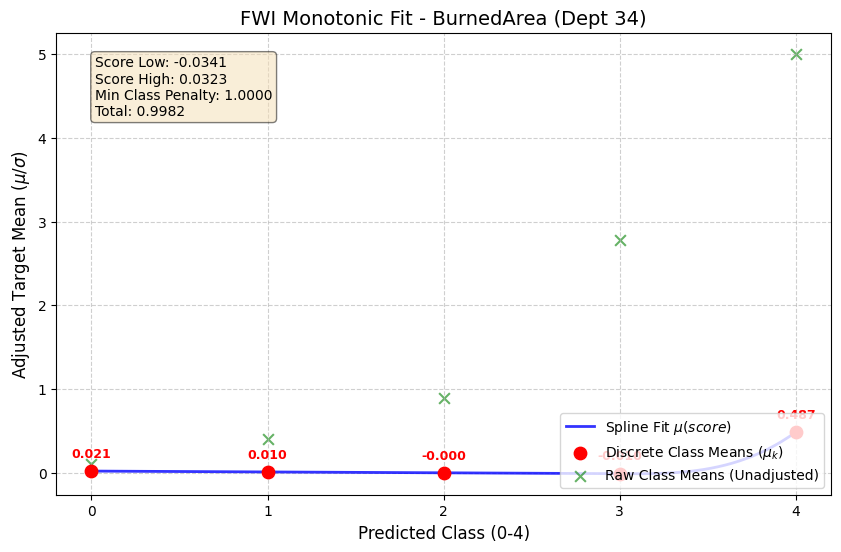

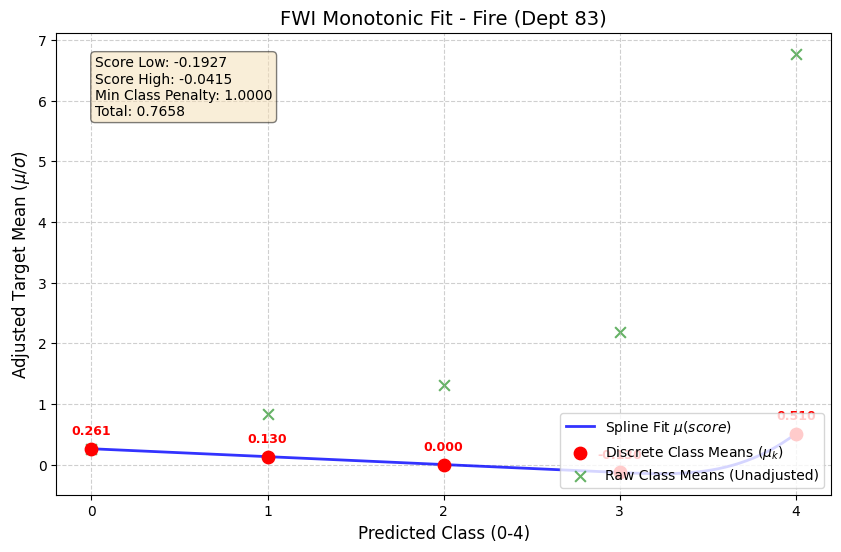

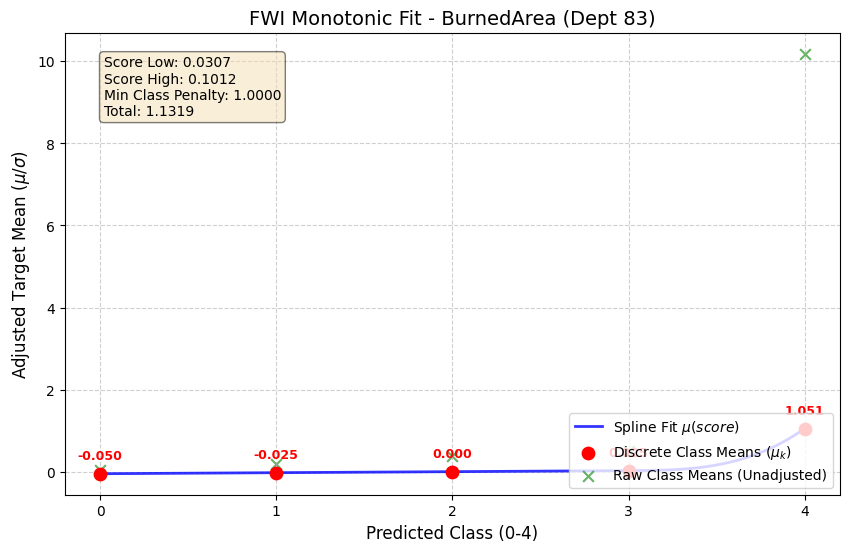

In [ ]:
from sklearn.metrics import recall_score
from pathlib import Path
import numpy as np

print('FWI Scoring Analysis')
FWI_QUANTILES = [0.0, 0.50, 0.75, 0.95, 0.99, 1.0]

def discretize_fwi(series, quantile_bounds, n_classes=5):
    qs = np.quantile(series.fillna(0), quantile_bounds[1:-1])
    return pd.Series(np.searchsorted(qs, series.fillna(0).values).clip(0, n_classes-1),
                     index=series.index, dtype=float)

target_map = {
    'Fire':      ('nbsinister',        'full_fire_df'),
    'BurnedArea': ('burnedareaRoot',          'full_fire_df'),
}
min_n    = globals().get('min_n', 1)
min_gain = globals().get('fire_min_gain', [0.0]*4)
fwi_all_scores = {}

for label, (target_col, df_name) in target_map.items():
    print(f"\n--- FWI / {label} ---")
    df = globals().get(df_name)
    if df is None or 'fwi_mean' not in df.columns or target_col not in df.columns:
        print("  Skipped"); continue

    sc = scorers.get(label)
    if sc is None:
        print(f"  No scorer for {label}"); continue
    print(f"  sigma={sc.sigma:.4f}  pair_mean_deltas={sc.pair_mean_deltas}")

    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['_p']   = discretize_fwi(df['fwi_mean'], FWI_QUANTILES)

    def _sc(sub):
        try:
            sh,sl,cov,adj,smc,_,_ = sc.evaluation_scoring(
                sub['_p'], sub[target_col].fillna(0), sub['date'], sub['num_zone'],
                min_n=min_n, min_gain=min_gain, reference=False)
            from sklearn.metrics import recall_score as rs
            rec = rs(sub[target_col]>0, sub['_p']>0, zero_division=0)
            return {'score_high':sh,'score_low':sl,'score_min_class':smc,'recall':rec,
                    **{f'k{k}':float(adj.get(k,float('nan'))) for k in [1,2,3,4]},
                    **{f'cov_k{k}':int(cov.get(k,0)) for k in [1,2,3,4]}}
        except Exception as e:
            print(f"  err: {e}"); return None

    results = []
    r = _sc(df)
    if r:
        results.append({'Dataset':'Global',**r})
        print(f"  Global: high={r['score_high']:.4f}  k1={r['k1']:.4f}  recall={r['recall']:.4f}")
    for yr in sorted(df['date'].dt.year.unique()):
        mask = (df['date'].dt.year == yr)
        if not mask.any(): continue
        r = _sc(df[mask])
        if r: results.append({'Dataset': f"{yr}", **r})
        
        for dpt in sorted(df['departement'].unique()):
            mask = (df['date'].dt.year == yr) & (df['departement'] == dpt)
            if not mask.any(): continue
            r = _sc(df[mask])
            if r: results.append({'Dataset': f"{yr}_{dpt}", **r})
            
    if results:
        df_res = pd.DataFrame(results)
        print(df_res.to_string(index=False))
        out = Path(MODE)/f'fwi_scores_{label}.csv'
        out.parent.mkdir(exist_ok=True)
        df_res.to_csv(out, index=False)
        fwi_all_scores[label] = df_res
        print(f"  Saved -> {out}")

print('FWI done.')

for d in [13, 34, 83]:
    # --- Visualisation FWI (Dept 06) ---
    for label, (target_col, df_name) in target_map.items():
        df = globals().get(df_name)
        sc = scorers.get(label)
        if df is not None and sc is not None and 'fwi_mean' in df.columns:
            mask = df['departement'] == d
            sub = df[mask].copy(deep=True)
            sub['_p'] = discretize_fwi(sub['fwi_mean'], FWI_QUANTILES)
            sc._plot(sub['_p'], sub[target_col].fillna(0), sub['date'], sub['num_zone'], 
                    title=f"FWI Monotonic Fit - {label} (Dept {d})")

<Axes: >

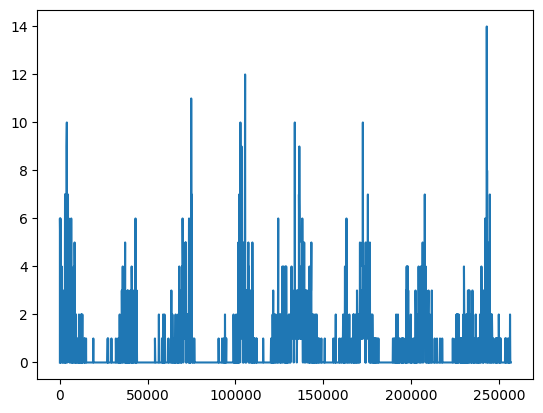

In [37]:
df[df['departement'] == 13]['nbsinister'].plot()

In [28]:
scorers['Fire'].pair_mean_deltas

{(0, 1): 2.6279656506423876,
 (1, 2): 2.8215566048741394,
 (2, 3): 3.9084656828110553,
 (3, 4): 7.664776921069635,
 (0, 2): 5.449522255516527,
 (1, 3): 6.730022287685195,
 (2, 4): 11.57324260388069,
 (0, 3): 9.357987938327582,
 (1, 4): 14.39479920875483,
 (0, 4): 17.022764859397217}

DFE Scoring...

--- DFE / Fire ---
  sigma=0.3795  pair_mean_deltas={(0, 1): 2.6279656506423876, (1, 2): 2.8215566048741394, (2, 3): 3.9084656828110553, (3, 4): 7.664776921069635, (0, 2): 5.449522255516527, (1, 3): 6.730022287685195, (2, 4): 11.57324260388069, (0, 3): 9.357987938327582, (1, 4): 14.39479920875483, (0, 4): 17.022764859397217}
  Global: high=0.0114  k1=-0.0246
Dataset  score_high  score_low  score_min_class   recall        k1        k2        k3        k4  cov_k1  cov_k2  cov_k3  cov_k4
 Global    0.011379  -0.033004              1.0 0.921502 -0.024632 -0.008371  0.004188  0.007191    3502    1786     646      60
   2017    0.113784   0.217482              0.0 1.000000  0.105205  0.112277  0.113784  0.000000      44      15       5       0
   2018    0.000000   0.291257              0.0 1.000000  0.140363  0.150894  0.000000  0.000000      28      10       0       0
   2019    0.801096   1.499993              0.0 1.000000  0.723520  0.776473  0.801096  0.000000      43   

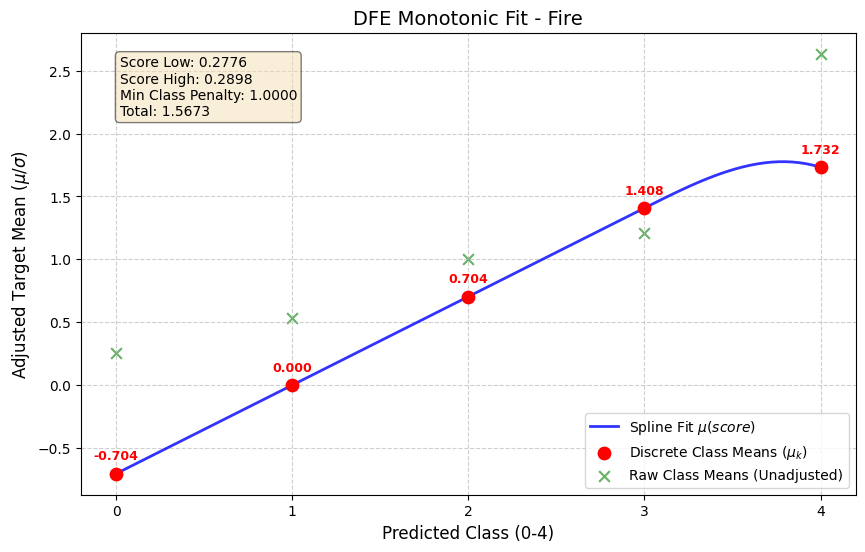

  Saved -> bdiff/dfe_scores_Fire.csv

--- DFE / BurnedArea ---
  sigma=73.3868  pair_mean_deltas={(0, 1): 0.5443217000925245, (1, 2): 2.3185576414210374, (2, 3): 3.5952861060380528, (3, 4): 8.473923528165347, (0, 2): 2.862879341513562, (1, 3): 5.91384374745909, (2, 4): 12.0692096342034, (0, 3): 6.458165447551615, (1, 4): 14.387767275624437, (0, 4): 14.932088975716962}
  Global: high=0.0196  k1=-0.0026
Dataset  score_high  score_low  score_min_class   recall        k1        k2       k3       k4  cov_k1  cov_k2  cov_k3  cov_k4
 Global    0.019636  -0.004588              1.0 0.923913 -0.002609 -0.001979 0.001461 0.018175    3502    1786     646      60
   2017    0.091380   0.181480              0.0 1.000000  0.088335  0.093146 0.091380 0.000000      44      15       5       0
   2018    0.000000   0.093723              0.0 1.000000  0.049983  0.043740 0.000000 0.000000      28      10       0       0
   2019    0.276540   0.464411              0.0 1.000000  0.203805  0.260606 0.276540 0

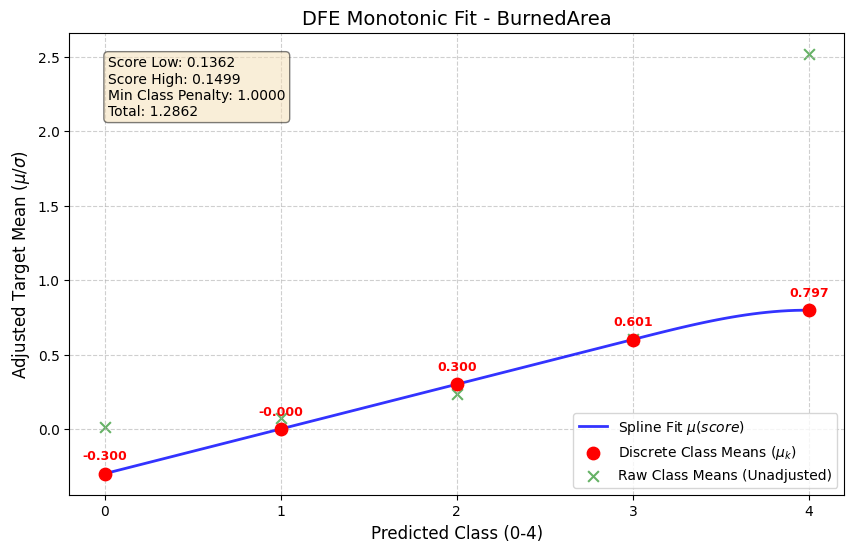

  Saved -> bdiff/dfe_scores_BurnedArea.csv
DFE done.


In [29]:
from pathlib import Path
from sklearn.metrics import recall_score
import numpy as np
print("DFE Scoring...")

target_map = {
'Fire':      ('nbsinister',        'full_fire_df'),
'BurnedArea': ('burnedareaRoot',          'full_fire_df'),
}

pred_col = 'DFE'
if pred_col not in full_dfe_df.columns:
    pred_col = 'prediction_DFE_0' if 'prediction_DFE_0' in full_dfe_df.columns else None
if pred_col is None: raise RuntimeError("No DFE column")

min_n    = globals().get('min_n', 1)
min_gain = globals().get('fire_min_gain', [0.0]*4)
keys = ['date','num_zone']
dfe_key = full_dfe_df[keys+[pred_col]].copy()
dfe_key['date'] = pd.to_datetime(dfe_key['date'])
dfe_all_scores = {}

for tname, (tcol, df_var) in target_map.items():
    print(f"\n--- DFE / {tname} ---")
    gt_df = globals().get(df_var)
    if gt_df is None or tcol not in gt_df.columns: print("  Skipped"); continue

    sc = scorers.get(tname)
    if sc is None:
        print(f"  No scorer for {tname}"); continue
    print(f"  sigma={sc.sigma:.4f}  pair_mean_deltas={sc.pair_mean_deltas}")

    gt_df = gt_df.copy()
    gt_df['date'] = pd.to_datetime(gt_df['date'])
    safe  = 'dfe_pred'
    merged = gt_df.merge(dfe_key.rename(columns={pred_col:safe}), on=keys, how='left')
    merged = merged.dropna(subset=[safe])
    
    def _sc(sub):
        try:
            sh,sl,cov,adj,smc,_,_ = sc.evaluation_scoring(
                sub[safe], sub[tcol].fillna(0), sub['date'], sub['num_zone'],
                min_n=min_n, min_gain=min_gain, reference=False)
            rec = recall_score(sub[tcol]>0, sub[safe]>0, zero_division=0)
            return {'score_high':sh,'score_low':sl,'score_min_class':smc,'recall':rec,
                    **{f'k{k}':float(adj.get(k,float('nan'))) for k in [1,2,3,4]},
                    **{f'cov_k{k}':int(cov.get(k,0)) for k in [1,2,3,4]}}
        except Exception as e:
            print(f"  err: {e}"); return None

    results = []
    r = _sc(merged)
    if r:
        results.append({'Dataset':'Global',**r})
        print(f"  Global: high={r['score_high']:.4f}  k1={r['k1']:.4f}")
    # DFE is only applied to department 6
    merged = merged[merged['departement'] == 6]
    
    for yr in sorted(merged['date'].dt.year.unique()):
        r = _sc(merged[merged['date'].dt.year==yr])
        if r: results.append({'Dataset':str(yr),**r})
    if results:
        df_res = pd.DataFrame(results)
        print(df_res.to_string(index=False))
        out = Path(MODE)/f'dfe_scores_{tname}.csv'
        out.parent.mkdir(exist_ok=True)
        df_res.to_csv(out, index=False)
        dfe_all_scores[tname] = df_res
        # --- Visualisation DFE ---
        sc._plot(merged[safe], merged[tcol].fillna(0), merged['date'], merged['num_zone'], 
                    title=f"DFE Monotonic Fit - {tname}")

        print(f"  Saved -> {out}")
        
print("DFE done.")